### Практическая работа №9: Плотностная кластеризация

Выполнил: Чашин Денис, ЕТ-128

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

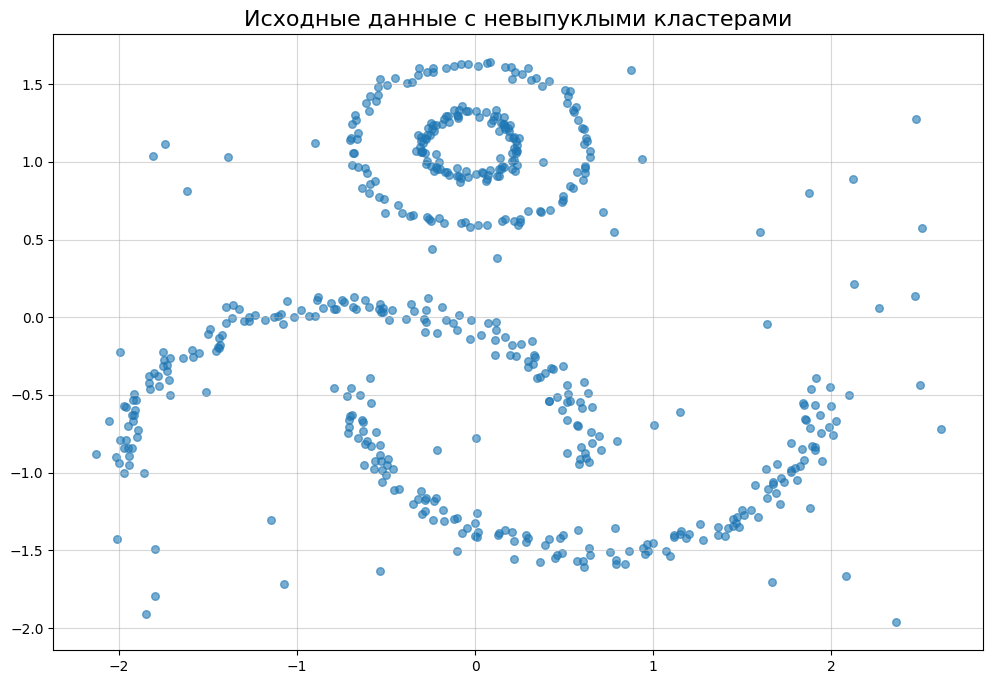

In [12]:
# Создание набора данных
circles_data, circles_labels = make_circles(n_samples=200, noise=0.04, factor=0.4, random_state=29)
circles_data = circles_data + np.array([1, 4])
moons_data, moons_labels = make_moons(n_samples=300, noise=0.05, random_state=29)
moons_data = moons_data * 2
noise_data = np.random.uniform(low=-2, high=5, size=(50, 2))

X = np.vstack([moons_data, circles_data, noise_data])

X_scaled = StandardScaler().fit_transform(X)

plt.rcParams['figure.figsize'] = (16, 10)
plt.figure(figsize=(12, 8))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.6, s=30)
plt.title('Исходные данные с невыпуклыми кластерами', fontsize=16)
plt.grid(True, alpha=0.5)
plt.show()

In [4]:
# Функция вывода результатов
def plot_dbscan_results(X, labels, eps, min_pts, ax):
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels[unique_labels != -1])
    colors = plt.cm.Set1(np.linspace(0, 1, len(unique_labels)))

    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = 'black'
            marker = 'x'
            size = 30
            alpha = 0.5
        else:
            marker = 'o'
            size = 40
            alpha = 0.8

        class_member_mask = (labels == k)
        xy = X[class_member_mask]
        ax.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=size,
                  alpha=alpha, edgecolors='white', linewidth=0.5)

    ax.set_title(f'DBSCAN: eps={eps:.2f}, MinPts={min_pts}\n'
                f'Кластеров: {n_clusters}', fontsize=12)
    ax.grid(True, alpha=0.5)

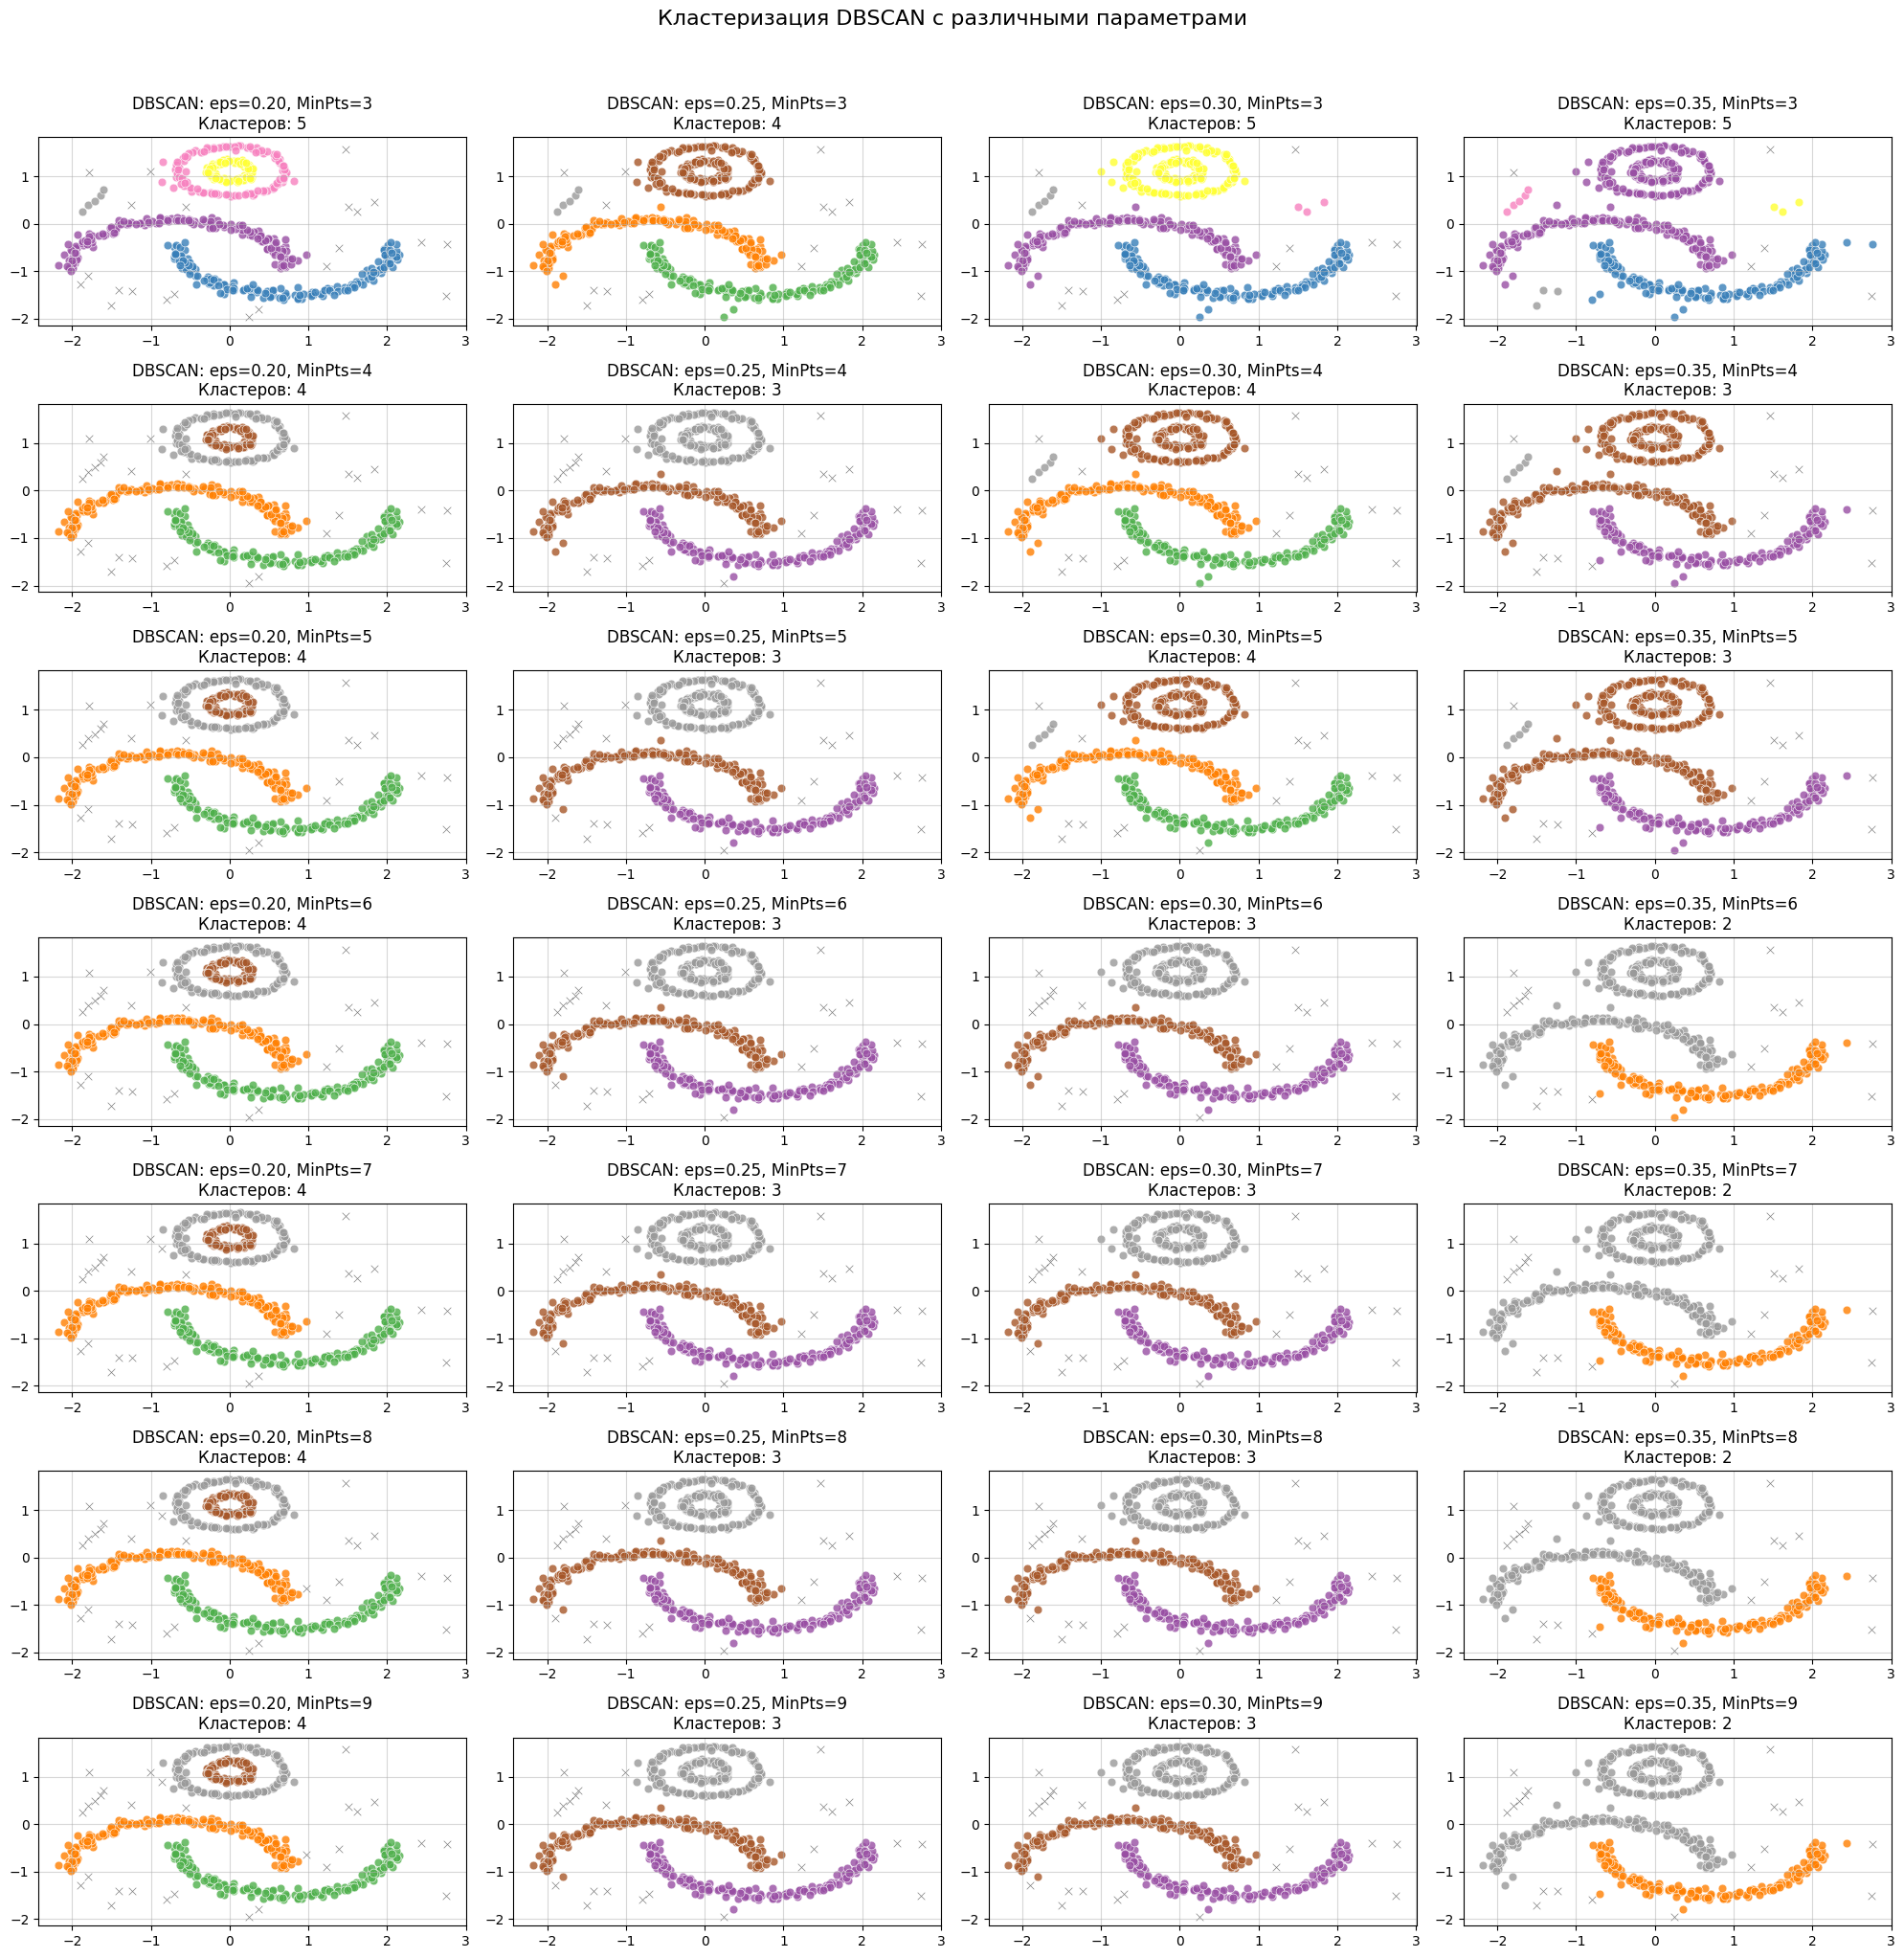

In [5]:
# Обучения моделей
eps_values = [0.2, 0.25, 0.3, 0.35]          # Радиус окрестности точки
min_pts_values = [3, 4, 5, 6, 7, 8, 9]       # Минимальное количество точек в окрестности

fig, axes = plt.subplots(len(min_pts_values), len(eps_values), figsize=(20, 20))
fig.suptitle('Кластеризация DBSCAN с различными параметрами', fontsize=16, y=1.02)

for i, min_pts in enumerate(min_pts_values):
    for j, eps in enumerate(eps_values):
        # Применяем DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_pts)
        labels = dbscan.fit_predict(X_scaled)

        # Визуализируем
        plot_dbscan_results(X_scaled, labels, eps, min_pts, axes[i, j])

plt.tight_layout()
plt.show()

### Кластеризация набора данных из задания разделительной кластеризации

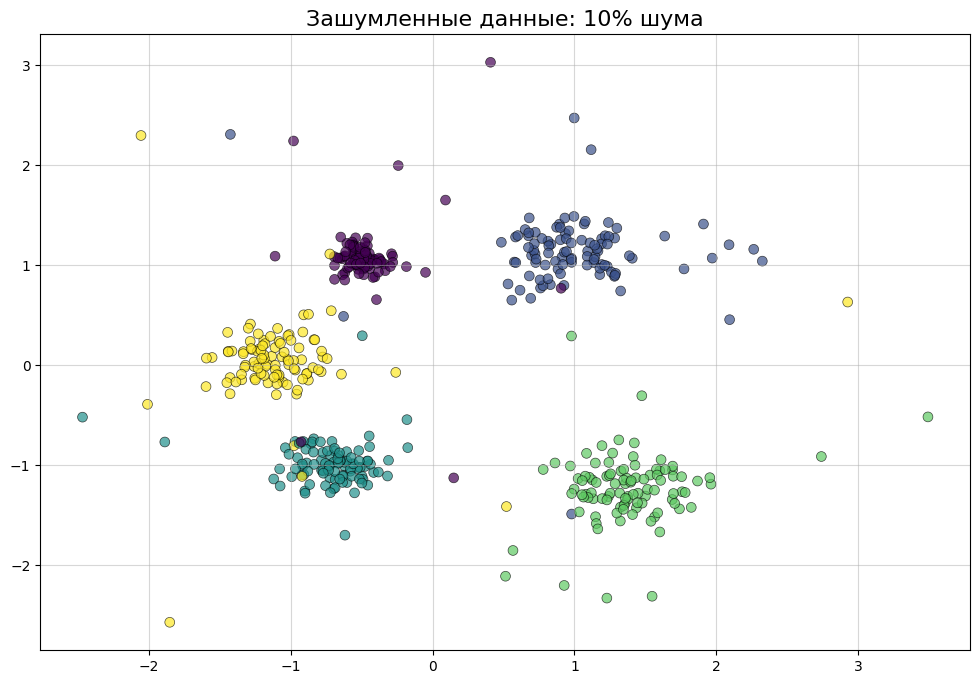

In [10]:
np.random.seed(31)
X2, y_true = make_blobs(n_samples=500,
                       centers=5,
                       cluster_std=[0.7, 1.5, 1.2, 1.5, 1.4],
                       random_state=31)

scaler = StandardScaler()
X2 = scaler.fit_transform(X2)

# Функция добавления шума
def add_noise(data, noise_percentage, noise_magnitude=0.5):
    data_noisy = data.copy()
    n_points = len(data)
    n_noisy = int(n_points * noise_percentage / 100)

    noisy_indices = np.random.choice(n_points, n_noisy, replace=False)

    for idx in noisy_indices:
        noise = np.random.randn(data.shape[1]) * noise_magnitude
        data_noisy[idx] += noise

    return data_noisy, noisy_indices


# Выведем зашумленный график
noise_pct = 10
X2_noisy, _ = add_noise(X2, noise_pct, noise_magnitude=1.0)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(X2_noisy[:, 0], X2_noisy[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.7, edgecolors='black', linewidth=0.5)

plt.title(f'Зашумленные данные: {noise_pct}% шума', fontsize=16)
plt.grid(True, alpha=0.5)

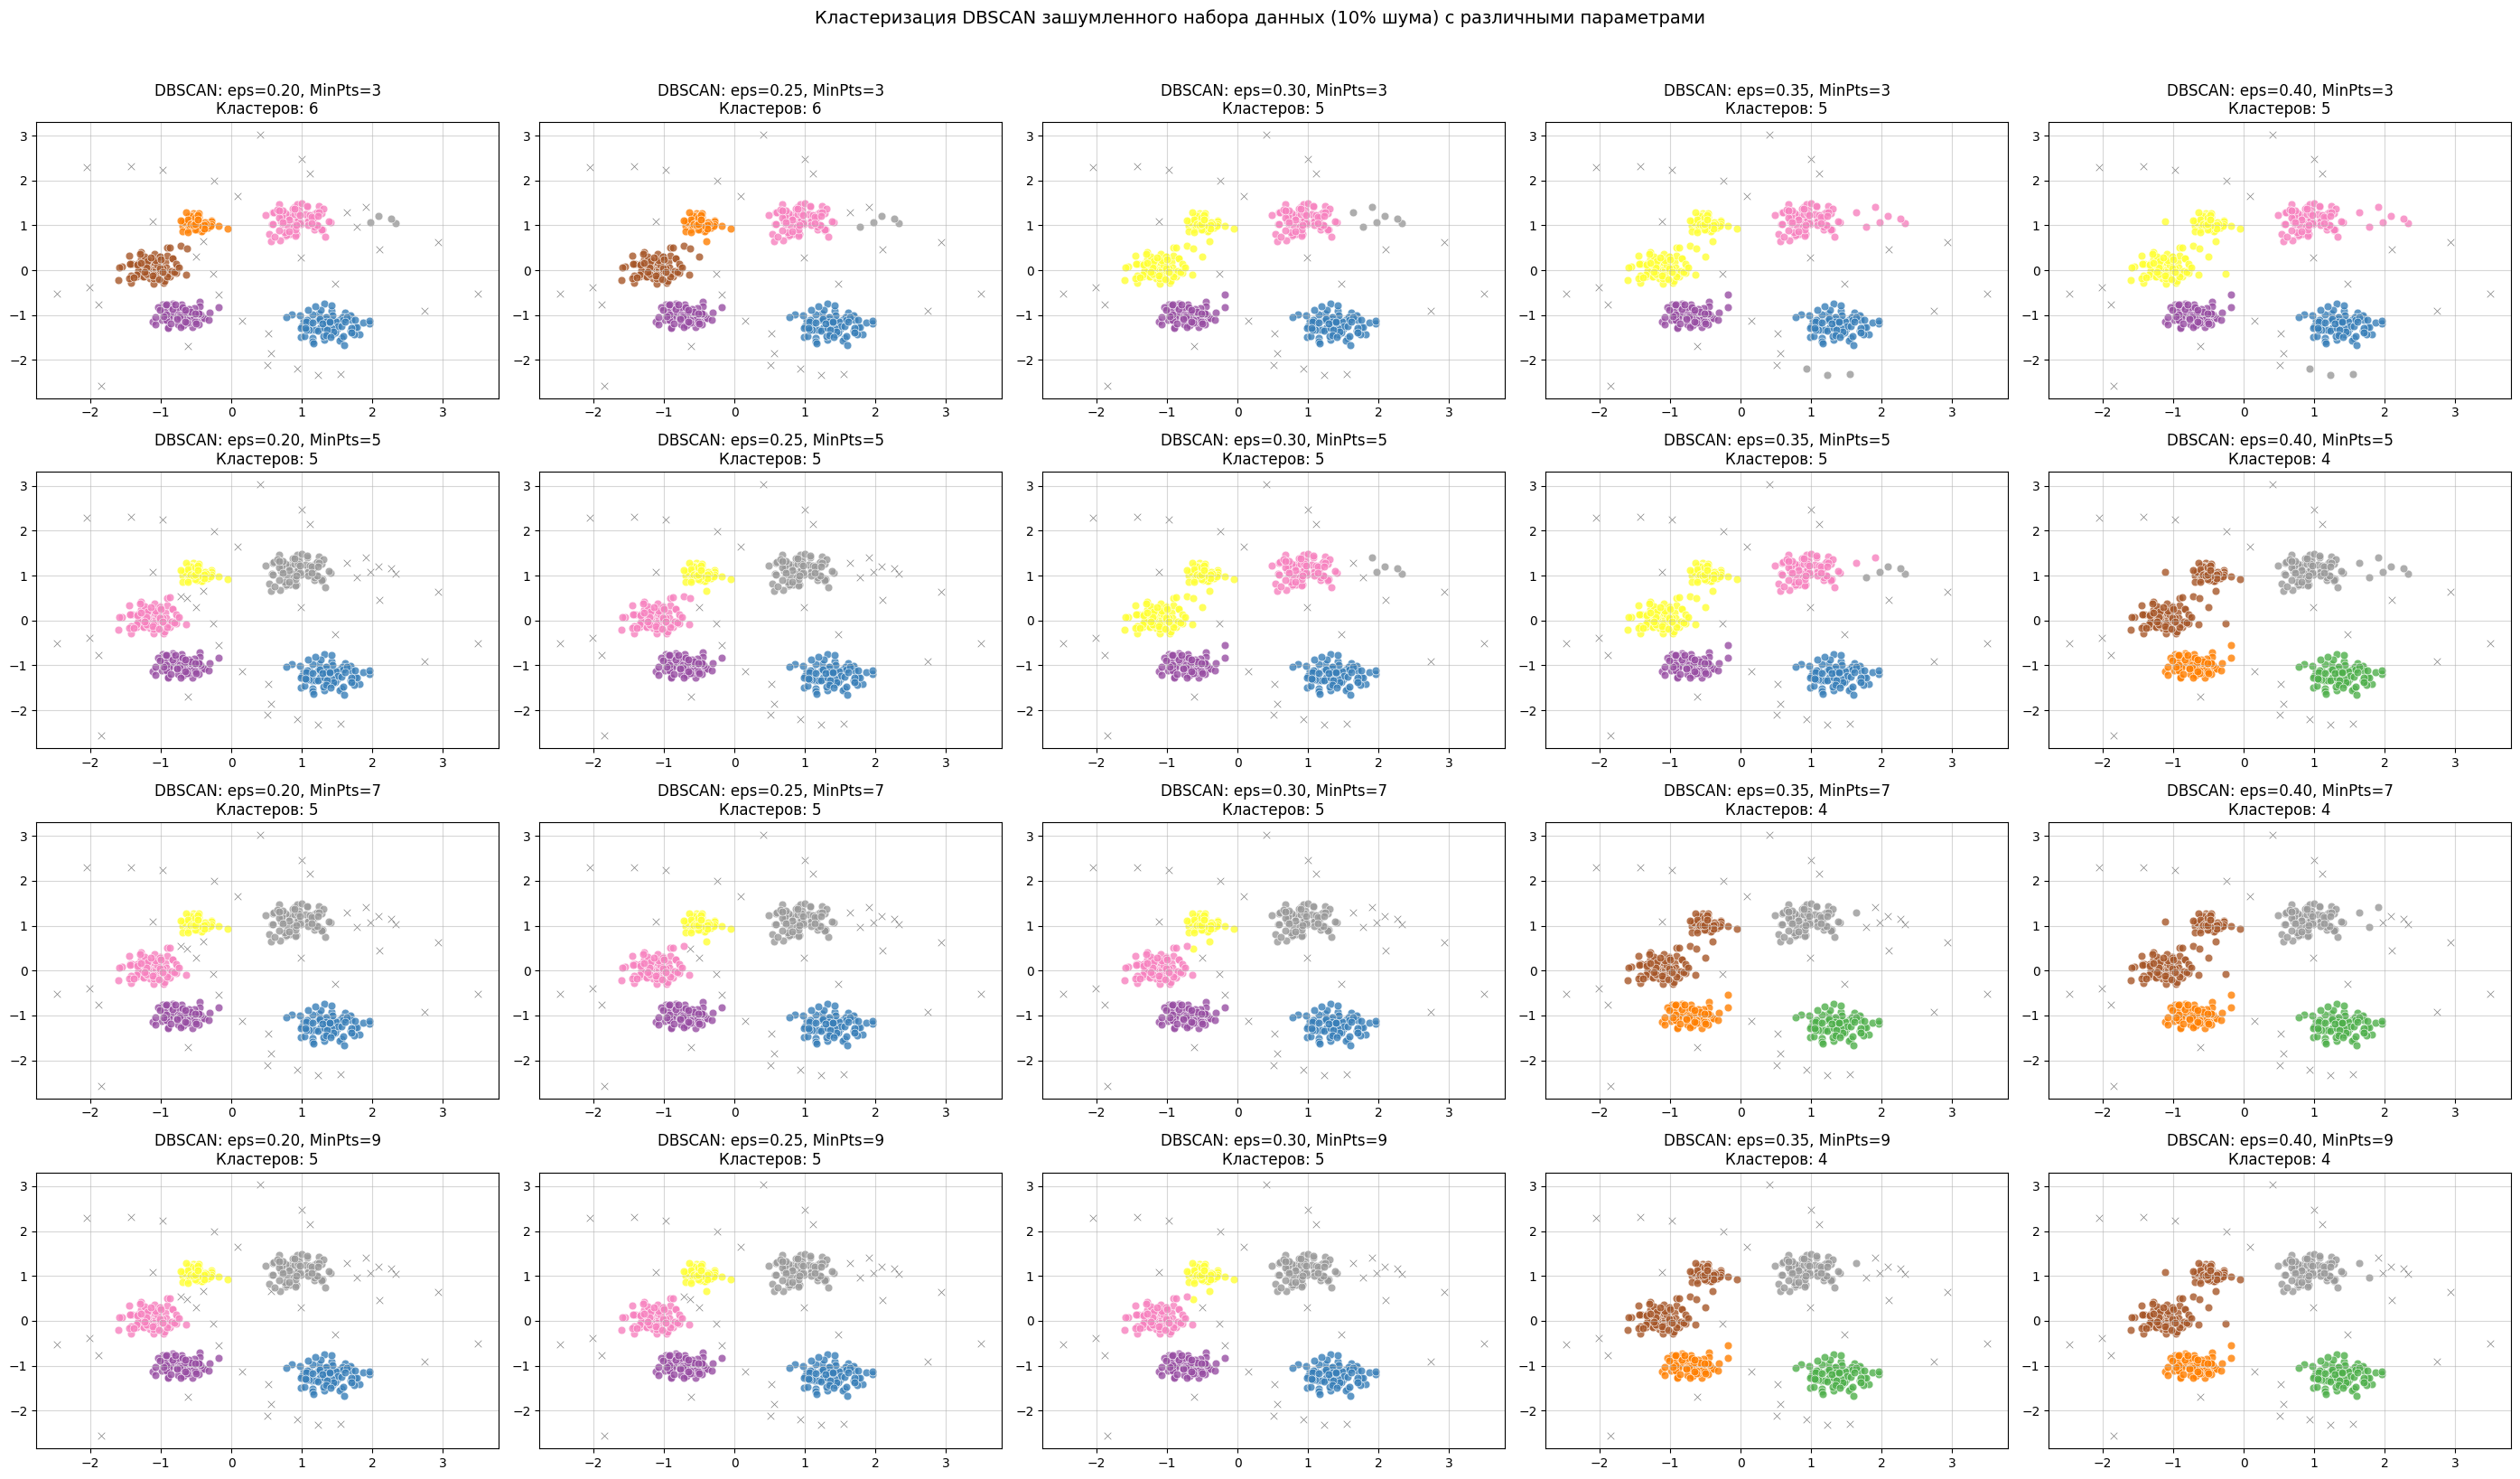

In [11]:
eps_values_2 = [0.2, 0.25, 0.3, 0.35, 0.4]
min_pts_values_2 = [3, 5, 7, 9]

fig, axes = plt.subplots(len(min_pts_values_2), len(eps_values_2), figsize=(28, 16))
fig.suptitle('Кластеризация DBSCAN зашумленного набора данных (10% шума) с различными параметрами', fontsize=14, y=1.02)

for i, min_pts in enumerate(min_pts_values_2):
    for j, eps in enumerate(eps_values_2):
        # Применяем DBSCAN к зашумленным данным
        dbscan = DBSCAN(eps=eps, min_samples=min_pts)
        labels = dbscan.fit_predict(X2_noisy)

        # Визуализируем результат
        plot_dbscan_results(X2_noisy, labels, eps, min_pts, axes[i, j])

plt.tight_layout()
plt.show()